Clean the data

IMPORTS

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

visualize data

/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/2387352285.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  s=pd.read_csv('../data/raw/cleaned_merged_seasons.csv')


<Axes: >

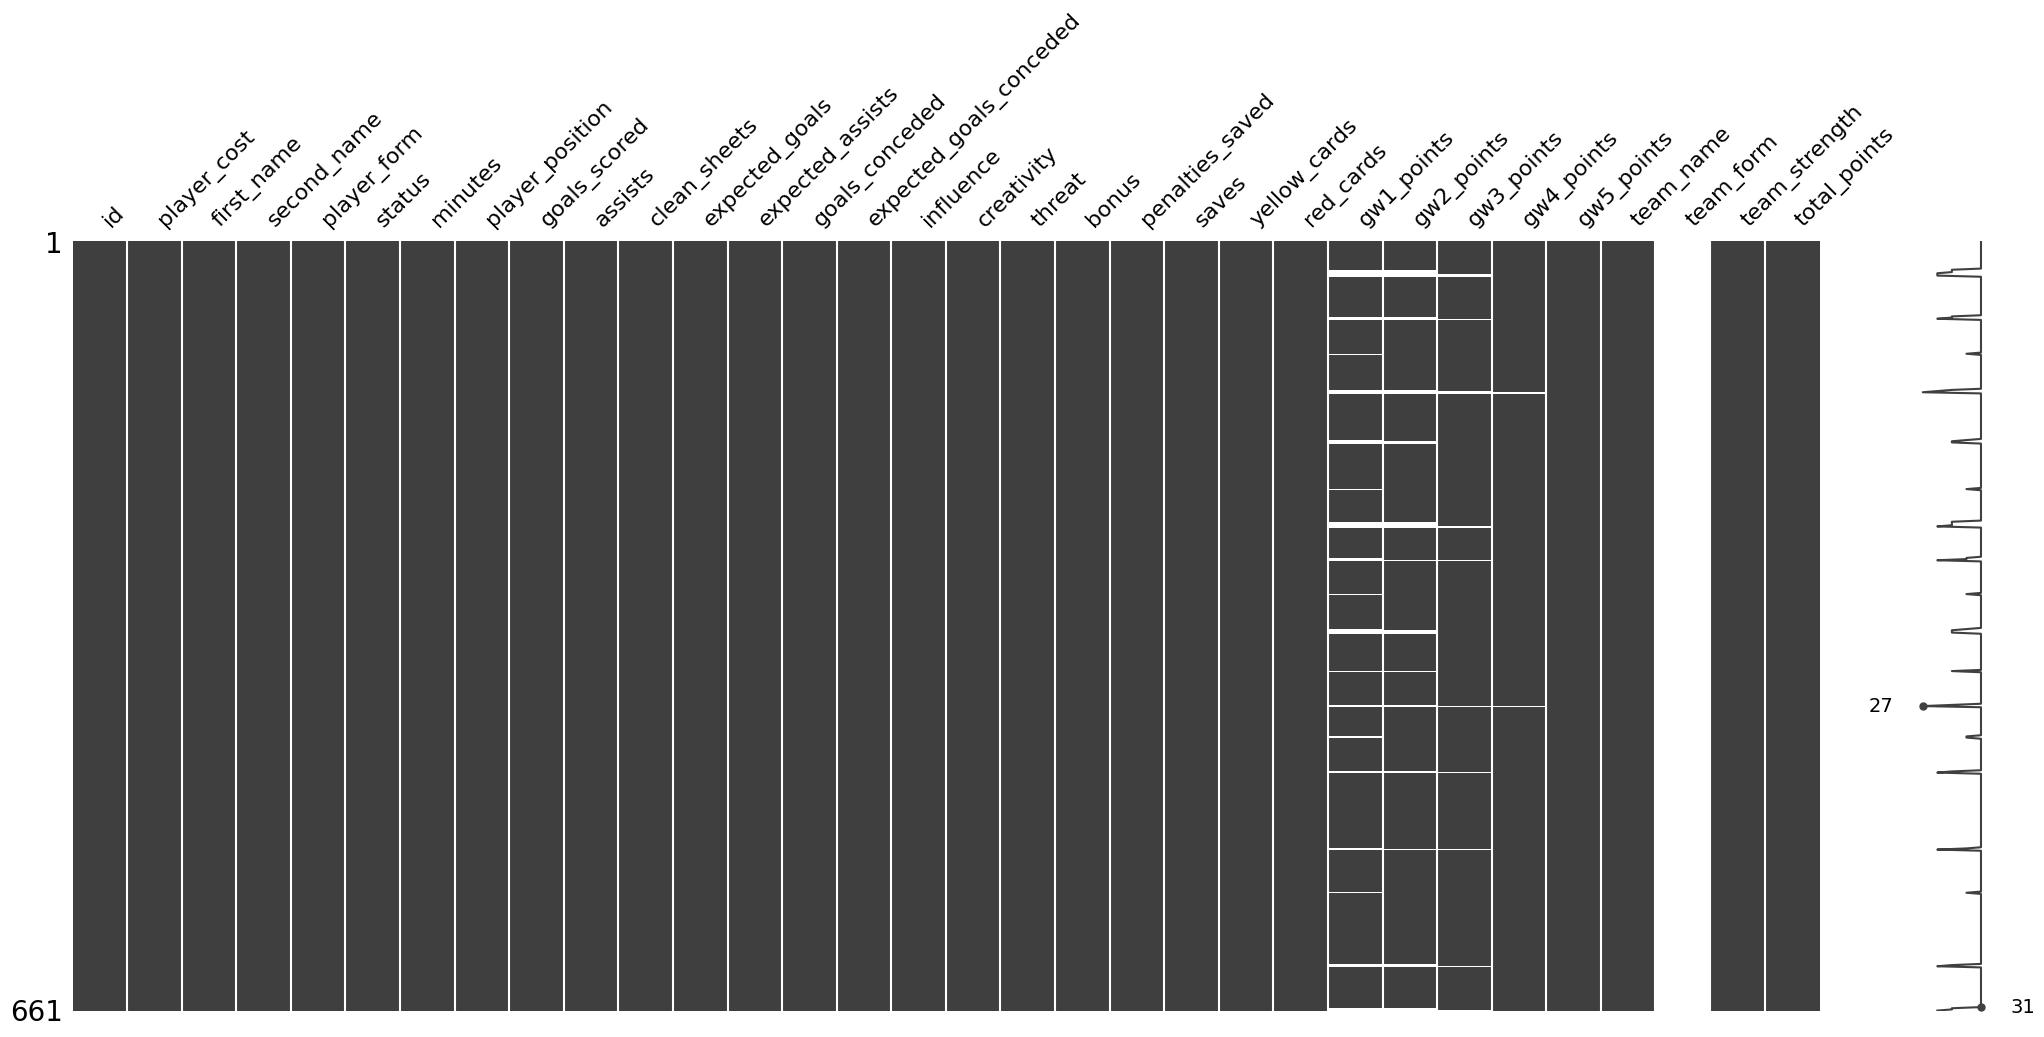

In [22]:
tl=pd.read_csv('../data/raw/master_team_list.csv')
ps=pd.read_csv('../data/raw/fpl_playerstats_2024-25.csv')
s=pd.read_csv('../data/raw/cleaned_merged_seasons.csv')
msno.matrix(ps)



<Axes: >

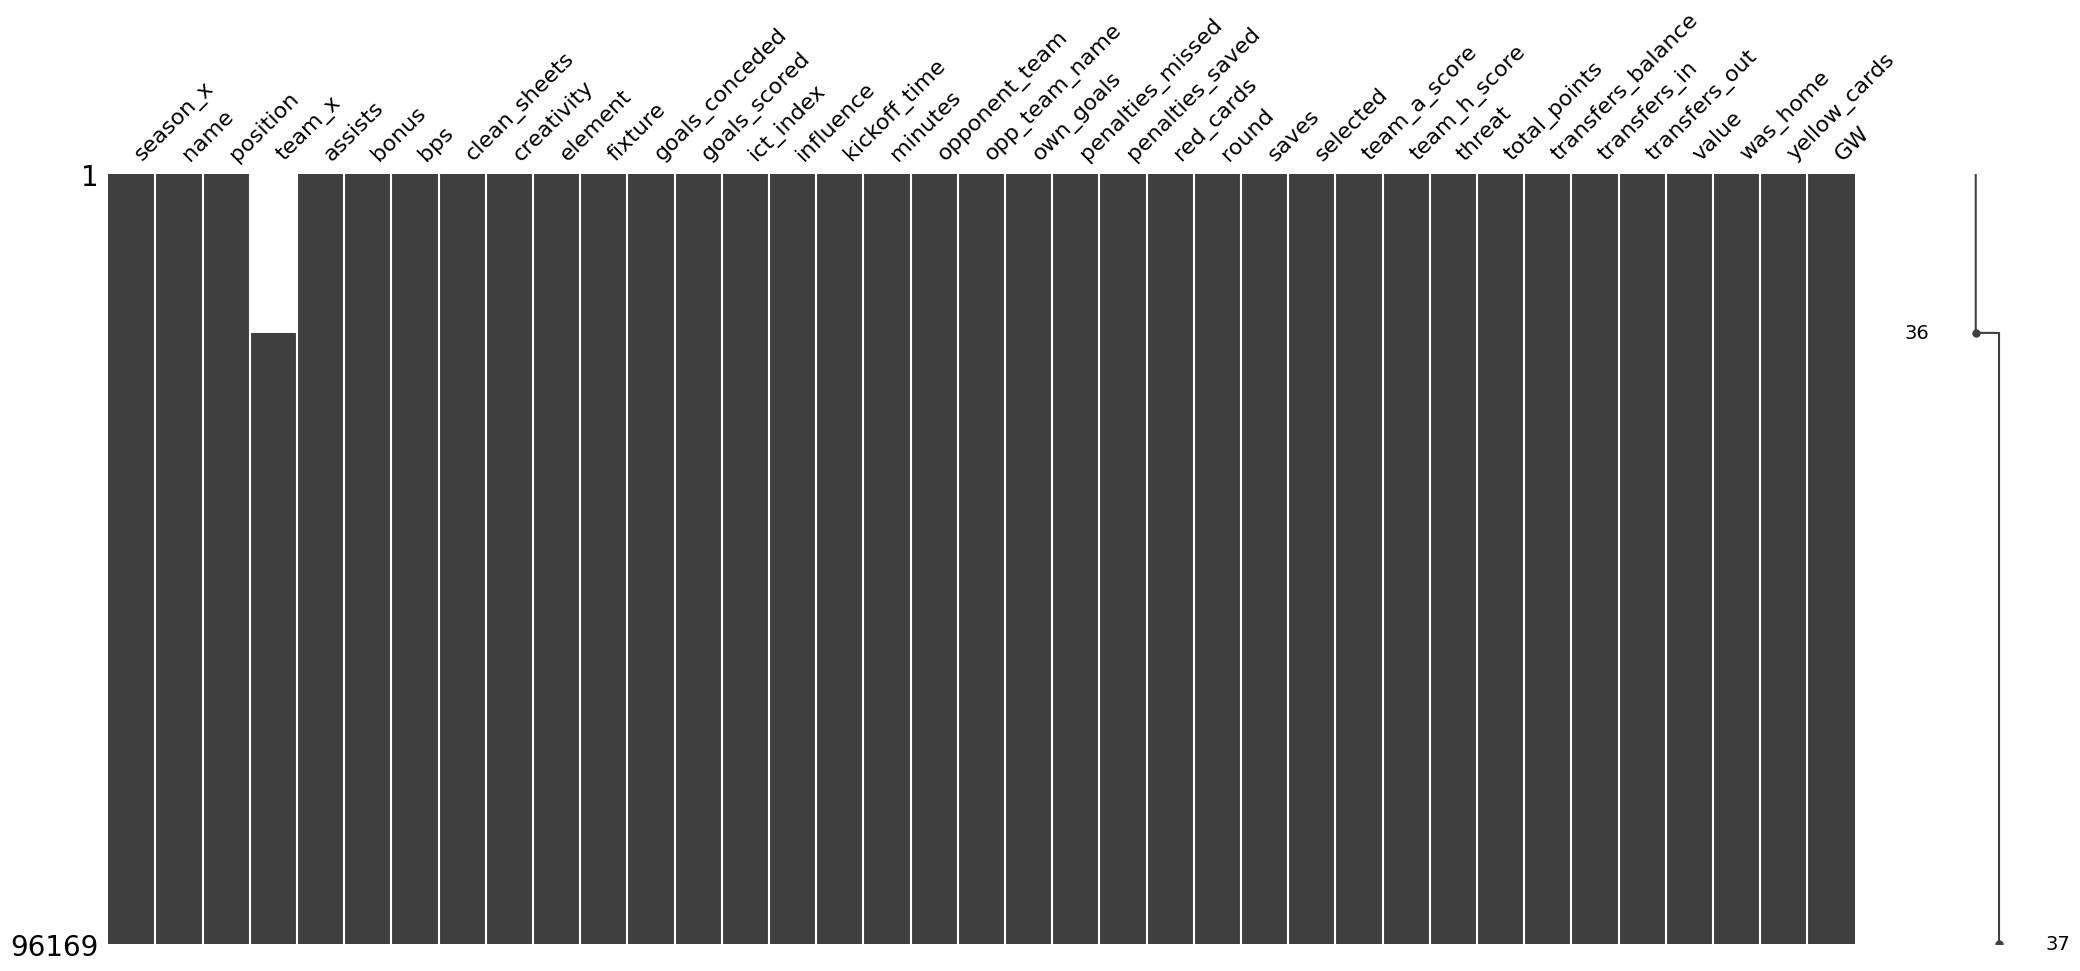

In [23]:
msno.matrix(s)

drop team form from player stat

In [24]:

if 'team_form' in ps.columns:
    ps = ps.drop('team_form', axis=1)
    print("team_form column dropped successfully")
else:
    print("team_form column not found in DataFrame")


team_form column dropped successfully


fill missing game weeks with 0

In [25]:

gw_columns = ['gw1_points', 'gw2_points', 'gw3_points', 'gw4_points', 'gw5_points']
ps[gw_columns] = ps[gw_columns].fillna(0)

print("Missing values after filling with 0:")
print(ps[gw_columns].isna().sum())

Missing values after filling with 0:
gw1_points    0
gw2_points    0
gw3_points    0
gw4_points    0
gw5_points    0
dtype: int64


fill missing season team values by checking where that player played next season

In [26]:
# Convert season to a sortable format and ensure proper ordering
def season_to_year(season_str):
    """Convert '2016-17' to 2016 for sorting"""
    return int(season_str.split('-')[0])

# Add a sortable season column
s['season_year'] = s['season_x'].apply(season_to_year)

# Sort by player name, season year, and gameweek to get chronological order
s = s.sort_values(['name', 'season_year', 'GW']).reset_index(drop=True)

print("Data sorted chronologically by player, season, and gameweek")

Data sorted chronologically by player, season, and gameweek


In [27]:
def chronological_team_fill(player_data):
    """
    Fill missing team values chronologically:
    1. Forward fill within same season (assumes player stays with team)
    2. Use most recent known team from previous seasons
    3. Backward fill if no previous data available
    """
    # Ensure data is sorted chronologically
    player_data = player_data.sort_values(['season_year', 'GW'])
    
    # Method 1: Forward fill within each season
    player_data['team_x'] = player_data.groupby('season_x')['team_x'].fillna(method='ffill')
    
    # Method 2: Forward fill across seasons (carry team from previous season)
    player_data['team_x'] = player_data['team_x'].fillna(method='ffill')
    
    # Method 3: Backward fill for any remaining (if player's first entries are missing)
    player_data['team_x'] = player_data['team_x'].fillna(method='bfill')
    
    return player_data

# Apply chronological filling
s = s.groupby('name').apply(chronological_team_fill).reset_index(drop=True)

print(f"After chronological fill - Missing team_x: {s['team_x'].isnull().sum()}")

/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/325313817.py:12: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  player_data['team_x'] = player_data.groupby('season_x')['team_x'].fillna(method='ffill')
/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/325313817.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  player_data['team_x'] = player_data.groupby('season_x')['team_x'].fillna(method='ffill')
/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/325313817.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  player_data['team_x'] = player_data['team_x'].fillna(method='ffill')
/var/

After chronological fill - Missing team_x: 0


/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/325313817.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s = s.groupby('name').apply(chronological_team_fill).reset_index(drop=True)


In [28]:
# Check a sample player to verify chronological order and team filling
sample_player = s[s['name'] == 'Aaron Ramsey'].copy()
print("Sample player data (chronologically sorted):")
print(sample_player[['name', 'season_x', 'GW', 'team_x', 'season_year']].head(15))

# Check for any impossible team changes within a season
def check_impossible_transfers(group):
    for season in group['season_x'].unique():
        season_data = group[group['season_x'] == season]
        teams_in_season = season_data['team_x'].dropna().unique()
        if len(teams_in_season) > 1:
            return f"Multiple teams in {season}: {teams_in_season}"
    return "OK"

transfer_check = s.groupby('name').apply(check_impossible_transfers)
suspicious_players = transfer_check[transfer_check != "OK"]
print("\nPlayers with potential transfer issues:")
print(suspicious_players.head())

Sample player data (chronologically sorted):
             name season_x  GW       team_x  season_year
639  Aaron Ramsey  2016-17   1  Aston Villa         2016
640  Aaron Ramsey  2016-17   2  Aston Villa         2016
641  Aaron Ramsey  2016-17   3  Aston Villa         2016
642  Aaron Ramsey  2016-17   4  Aston Villa         2016
643  Aaron Ramsey  2016-17   5  Aston Villa         2016
644  Aaron Ramsey  2016-17   6  Aston Villa         2016
645  Aaron Ramsey  2016-17   7  Aston Villa         2016
646  Aaron Ramsey  2016-17   8  Aston Villa         2016
647  Aaron Ramsey  2016-17   9  Aston Villa         2016
648  Aaron Ramsey  2016-17  10  Aston Villa         2016
649  Aaron Ramsey  2016-17  11  Aston Villa         2016
650  Aaron Ramsey  2016-17  12  Aston Villa         2016
651  Aaron Ramsey  2016-17  13  Aston Villa         2016
652  Aaron Ramsey  2016-17  14  Aston Villa         2016
653  Aaron Ramsey  2016-17  15  Aston Villa         2016

Players with potential transfer issues:
na

/var/folders/fc/fzd23wl96_77j9wrb07qt2340000gn/T/ipykernel_39880/3736124510.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transfer_check = s.groupby('name').apply(check_impossible_transfers)


In [29]:
# Remove the helper column
s = s.drop('season_year', axis=1)

# Final check
print(f"Final missing team_x values: {s['team_x'].isnull().sum()}")
print(f"Total rows: {len(s)}")
print(f"Percentage filled: {(1 - s['team_x'].isnull().sum()/len(s))*100:.2f}%")

Final missing team_x values: 0
Total rows: 96169
Percentage filled: 100.00%


save files to cleaned folder

In [ ]:


# Save the cleaned datasets
print("Saving cleaned datasets...")

# Save the team list
tl.to_csv('src/data/cleaned/fpl_playerstats_2024-25_cleaned.csv', index=False)
print(" Saved: fpl_playerstats_2024-25_cleaned.csv")

# Save the sseason data
s.to_csv('src/data/cleaned/cleaned_merged_seasons_processed.csv', index=False)
print(" Saved: cleaned_merged_seasons_processed.csv")

# save the player stats
ps.to_csv('src/data/cleaned/fpl_playerstats_2024-25_cleaned.csv', index=False)
print(" Saved: fpl_playerstats_2024-25_cleaned.csv")


Saving cleaned datasets...


OSError: Cannot save file into a non-existent directory: 'src/data/cleaned'